In [19]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import sigpy.mri as mr
import numpy as np
import os
import jax as jx
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))

print(project_root)

import aymansigmri as asm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE


## Goal: Implement Algorithm 4.1

In [4]:
width=4
gap = 2
num_iters = 50

resize_wid=1024
rw_div2 = int(resize_wid/2)

inner_wid=100
indiv2 = int(inner_wid/2)

### Set up ZTE style data

In [42]:
zte_radial_kspacedlt, zte_radial_coordsdlt, zte_radial_kspacezero, zte_radial_coordszero, mask = asm.generate_zte_data(ksp=ksp, coord=coord, n_missing=(gap), undersampling_factor=1)


cartesian_zte = asm.nufft_gridding(kspace=zte_radial_kspacezero, coords=zte_radial_coordszero)

cartesian_kspace_enl = asm.zero_padding(cart_kspace=cartesian_zte, resize_x=resize_wid, resize_y=resize_wid)

inner_region, inner_mask, start, end = asm.inner_portion(enlarged_kspace=cartesian_kspace_enl, inner_sidelen=inner_wid)


im_grid0 = sp.ifft(cartesian_zte, axes=(-2, -1))
preloop = np.sum(np.abs(im_grid0)**2, axis=0)**0.5

zte_radial_kspace1, zte_radial_coords1 = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)
cartesian_nogap = asm.nufft_gridding(kspace=zte_radial_kspace1, coords=zte_radial_coords1)

dcf1 = (zte_radial_coords1[...,0]**2 + zte_radial_coords1[...,1]**2)**0.5
im_grid3 = sp.nufft_adjoint(zte_radial_kspace1* dcf1, zte_radial_coords1)
img_nogap = np.sum(np.abs(im_grid3)**2, axis=0)**0.5

### Build and plot mask - same as in cartesian testing

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


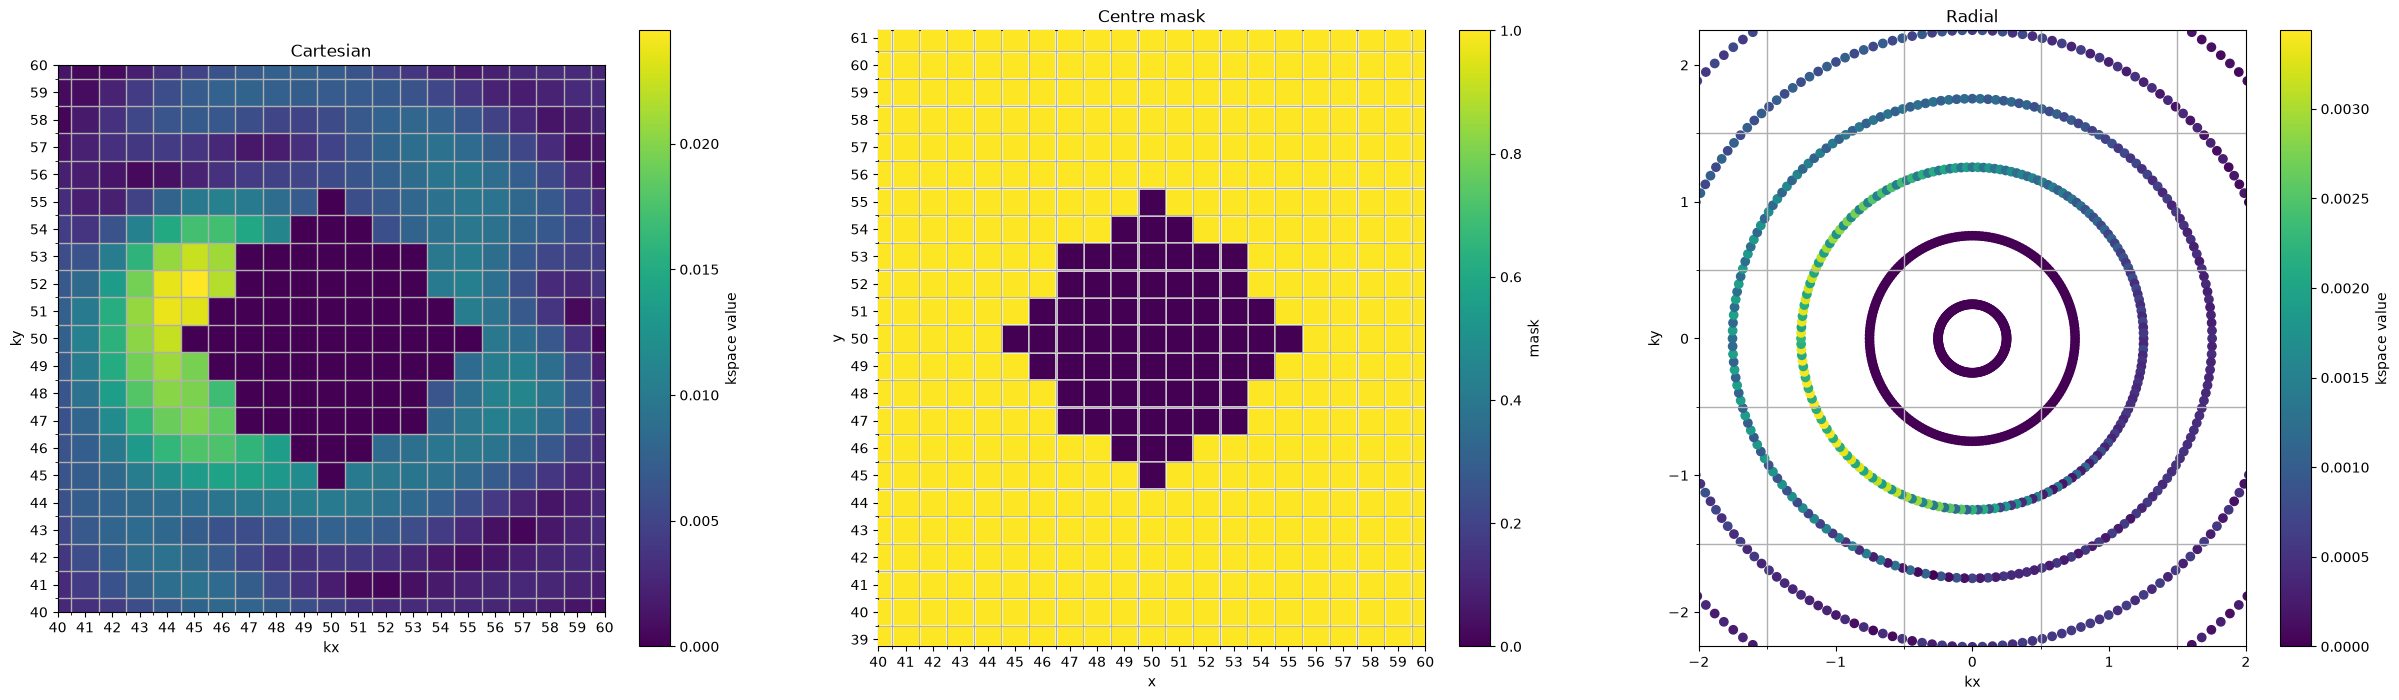

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


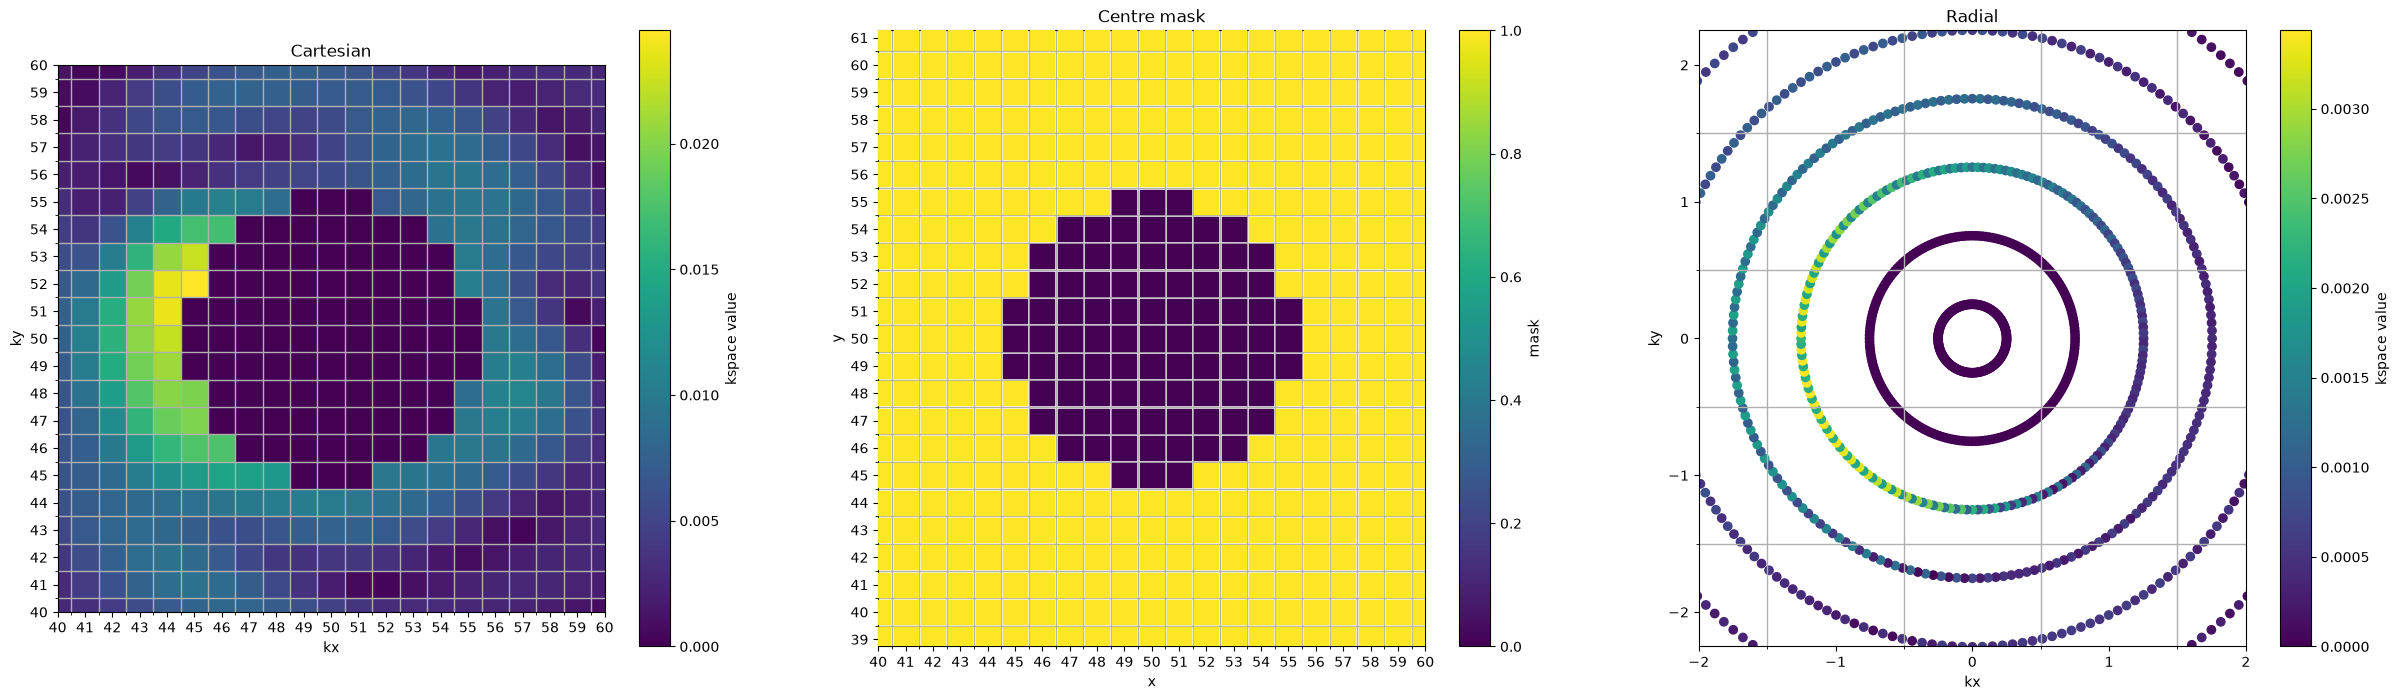

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


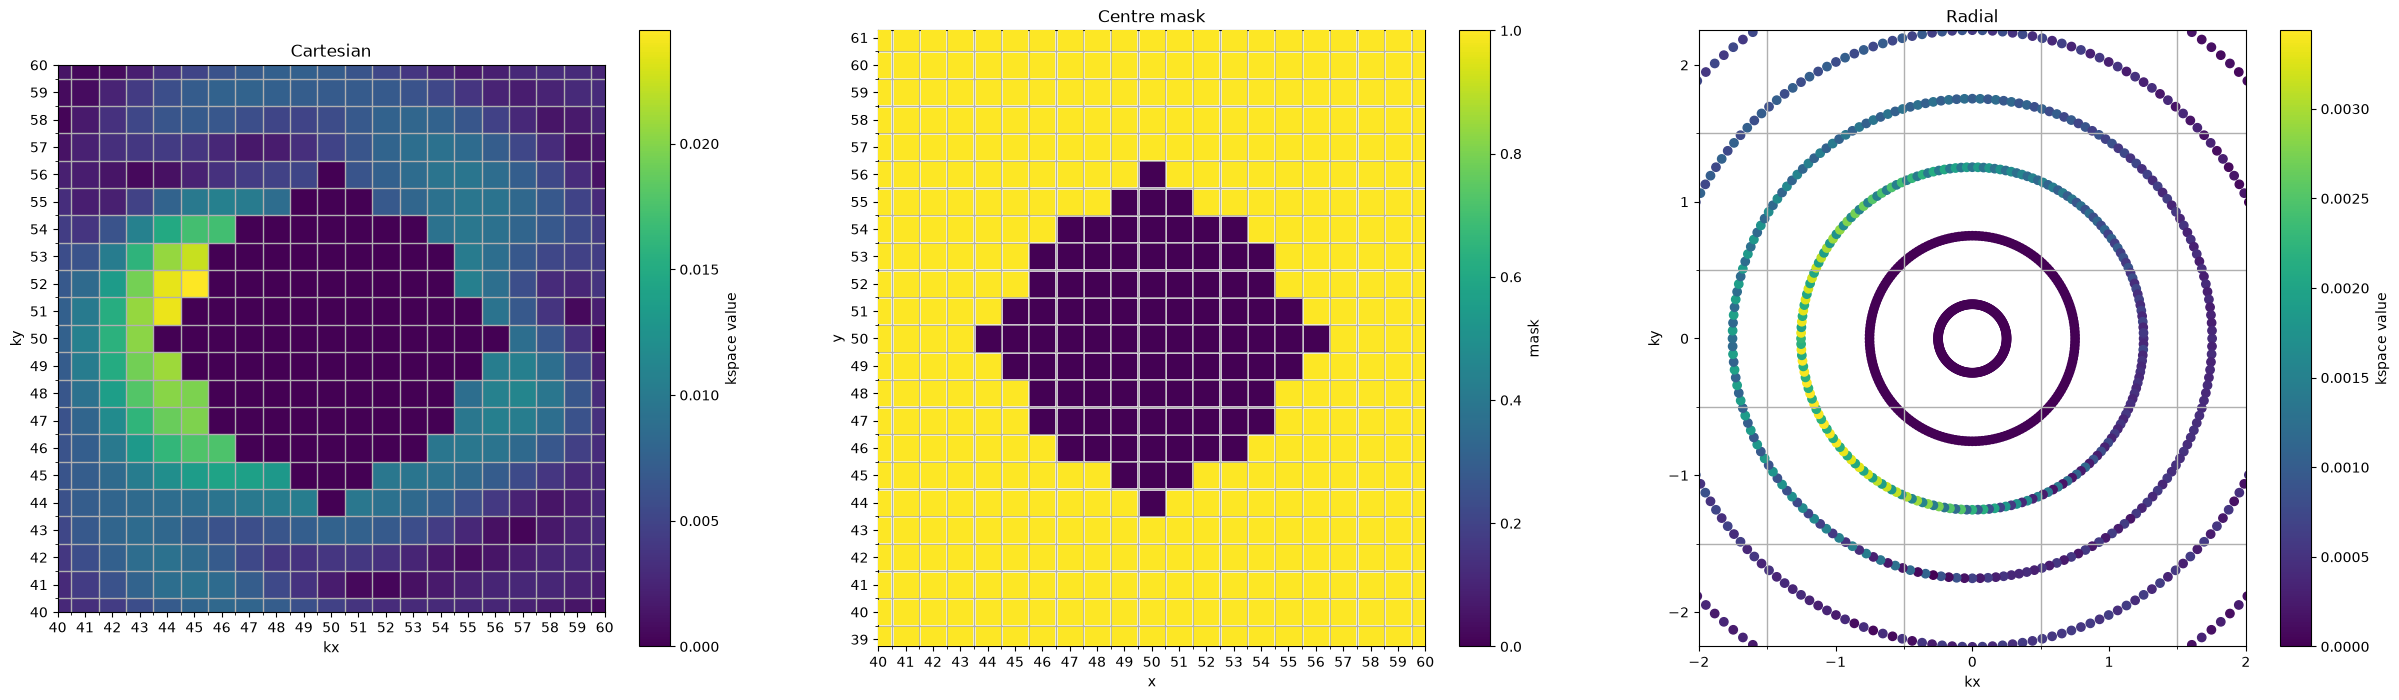

In [8]:
cy, cx = inner_wid // 2, inner_wid // 2
r = 4
yy, xx = np.ogrid[:inner_wid, :inner_wid]
maska = (yy - cy)**2 + (xx - cx)**2 > r**2 +2

maska[(cx-5):(cx+6), cy] = False
maska[(cx), (cy-5):(cy+6)] = False

inner_removeda = inner_region.copy()
inner_removeda[:,~maska] = 0


cy, cx = inner_wid // 2, inner_wid // 2
r = 5
yy, xx = np.ogrid[:inner_wid, :inner_wid]
maskb = (yy - cy)**2 + (xx - cx)**2 > r**2 +2

maskb[(cx-5):(cx+6), cy] = False
maskb[(cx), (cy-5):(cy+6)] = False

inner_removedb = inner_region.copy()
inner_removedb[:,~maskb] = 0

cy, cx = inner_wid // 2, inner_wid // 2
r = 5
yy, xx = np.ogrid[:inner_wid, :inner_wid]
maskc = (yy - cy)**2 + (xx - cx)**2 > r**2 +2

maskc[(cx-6):(cx+7), cy] = False
maskc[(cx), (cy-6):(cy+7)] = False

inner_removedc = inner_region.copy()
inner_removedc[:,~maskc] = 0


asm.plot_mask(inner_removeda, mask=maska, zte_radial_coords=zte_radial_coordszero, zte_radial_kspace=zte_radial_kspacezero, innersidelen=inner_wid,sidelencart=10,sidelenrad=4)
asm.plot_mask(inner_removedb, mask=maskb, zte_radial_coords=zte_radial_coordszero, zte_radial_kspace=zte_radial_kspacezero, innersidelen=inner_wid,sidelencart=10,sidelenrad=4)
asm.plot_mask(inner_removedc, mask=maskc, zte_radial_coords=zte_radial_coordszero, zte_radial_kspace=zte_radial_kspacezero, innersidelen=inner_wid,sidelencart=10,sidelenrad=4)


### Functions for inner loop and filling framework

In [48]:
def softimpute_ALS(X_H, M_H, rank, lamda, n_iters):
        I = np.eye(rank)
        m,n = np.shape(X_H)
        U = np.random.randn(m, rank) + 1j * np.random.randn(m, rank)
        V = np.random.randn(n, rank) + 1j * np.random.randn(n, rank)

        D = I.copy()


        A = np.dot(U,D)
        B = np.dot(V,D)
        iter_count = 0
        ABt = A @ B.conj().T
        
        while iter_count < n_iters:
            X_star = np.where(M_H, X_H, ABt)
            X_star1H = X_star.copy()
            A = X_star @ B @ np.linalg.inv(B.conj().T @ B + lamda*I)
            ABt = A @ B.conj().T
            X_star = np.where(M_H, X_H, ABt)
            B = X_star.conj().T @ A @ np.linalg.inv(A.conj().T @ A + lamda*I)
            ABt = A @ B.conj().T
            iter_count += 1
        return(ABt, X_star1H)

def LORAKS_imputeals(n_iters, window_size, cartesian_inputkspace, dtg_mask, rank, lamda, stride, im_dim):
    ksp_forhankel = cartesian_inputkspace.copy()
    ksp_zerod = ksp_forhankel * dtg_mask
    hankel_matrix, n_coils, Numx, Numy = asm.hankel_2(kspace=ksp_zerod, w=window_size, s=stride)
    mask_coiled = np.broadcast_to(dtg_mask, (cartesian_inputkspace.shape))
    masked_hankel, *_ = asm.hankel_2(kspace=mask_coiled, w=window_size, s=stride)
    masked_hankel = np.real(masked_hankel) > 0.5
    
    
    filled_hankel, X_star1 = softimpute_ALS(X_H = hankel_matrix, M_H = masked_hankel, rank = rank, lamda = lamda, n_iters=n_iters)

    kspace_cart_coils_recon = asm.hankel_H_averaged_2(filled_hankel, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size, s=stride)
    kspace_cart_coils_recon = np.where(dtg_mask, cartesian_inputkspace, kspace_cart_coils_recon)
    output_kspace = kspace_cart_coils_recon.copy()
    filled_ksp = rebuild(output_kspace=output_kspace, inner_mask = inner_mask, inner_start = start, inner_end = end, enlarged_kspace=cartesian_kspace_enl, resize_x = im_dim, resize_y = im_dim)
    im_grid0 = sp.ifft(filled_ksp, axes=(-2, -1))
    im_0 = np.sum(np.abs(im_grid0)**2, axis=0)**0.5

    return (im_0, filled_ksp, masked_hankel)


def rebuild(output_kspace, inner_mask, inner_start, inner_end, enlarged_kspace, resize_x, resize_y):
    recombined = asm.jigsaw(output_kspace=output_kspace, isolation_mask = inner_mask, start=inner_start, end=inner_end, enlarged_kspace=enlarged_kspace)
    filled_ksp = asm.zero_padding(recombined, resize_x, resize_y)
    return(filled_ksp)

def LORAKS_loop(n_iters, window_size, zero_thresh, cartesian_inputkspace, dtg_mask, stride, im_dim):
    ksp_forhankel = cartesian_inputkspace.copy()
    iter_count = 0
    deltas = []
    k_prev = None
    while iter_count < n_iters:
        hankel_matrix, n_coils, Numx, Numy = asm.hankel_2(kspace=ksp_forhankel, w=window_size,s=stride)
        U, S_reduced, Vh = asm.sig_val_thresholding_jax(data=hankel_matrix, zero_thresh=zero_thresh)
        data_recon = (U * S_reduced) @ Vh

        kspace_cart_coils_recon = asm.hankel_H_averaged_2(data_recon, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size, s=stride)
        kspace_cart_coils_consistent = kspace_cart_coils_recon.copy()

        for coil in range(ksp_forhankel.shape[0]):
            kspace_cart_coils_consistent[coil, dtg_mask] = cartesian_inputkspace[coil, dtg_mask]
        ksp_forhankel = kspace_cart_coils_consistent.copy()

        vec = ksp_forhankel[:, ~dtg_mask]

        if k_prev is not None:
            deltas.append(np.linalg.norm(vec - k_prev) / np.linalg.norm(k_prev))
        k_prev = vec.copy()
        iter_count += 1

    output_kspace = ksp_forhankel.copy()
    filled_ksp = rebuild(output_kspace=output_kspace, inner_mask = inner_mask, inner_start = start, inner_end = end, enlarged_kspace=cartesian_kspace_enl, resize_x = im_dim, resize_y = im_dim)
    im_grid0 = sp.ifft(filled_ksp, axes=(-2, -1))
    im_0 = np.sum(np.abs(im_grid0)**2, axis=0)**0.5
    
    return(im_0, filled_ksp, deltas)

## Testing

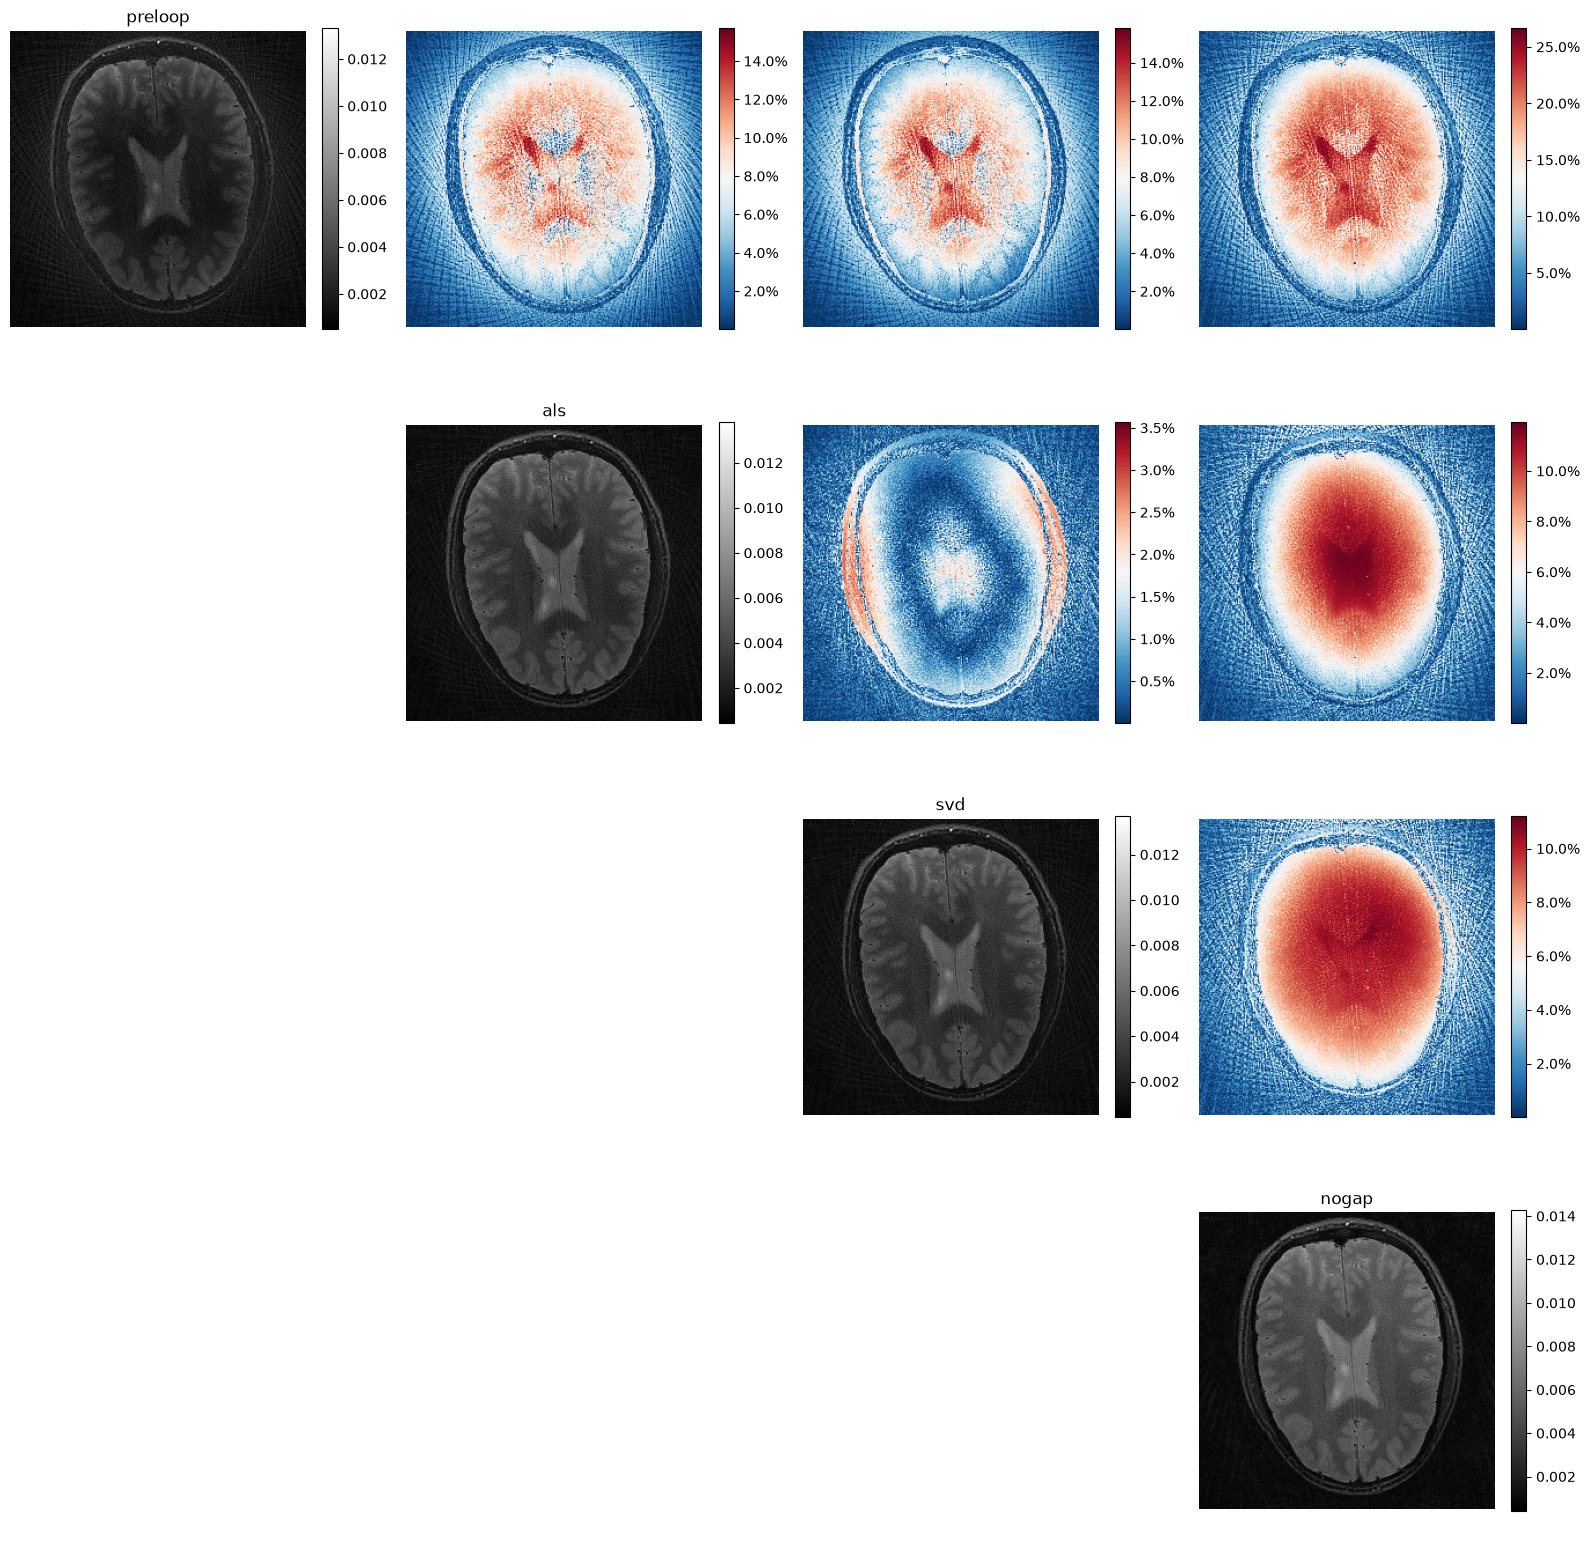

In [27]:
im_als, output_kspaceals, zeroed = LORAKS_imputeals(n_iters=50, window_size=10, cartesian_inputkspace=inner_region, dtg_mask=maskb, rank= 10, lamda = 5*10**-5, stride=1, im_dim=256)
ims_svd, output_kspacesvd, deltas = LORAKS_loop(n_iters=50, window_size=5, zero_thresh=0.2,cartesian_inputkspace=inner_region, dtg_mask=maskb, stride=1, im_dim=256)


test_results = {'preloop':preloop, 'als':im_als, 'svd': ims_svd,'nogap':img_nogap}

asm.diff_matrix(test_results)

## Iter_countSDV

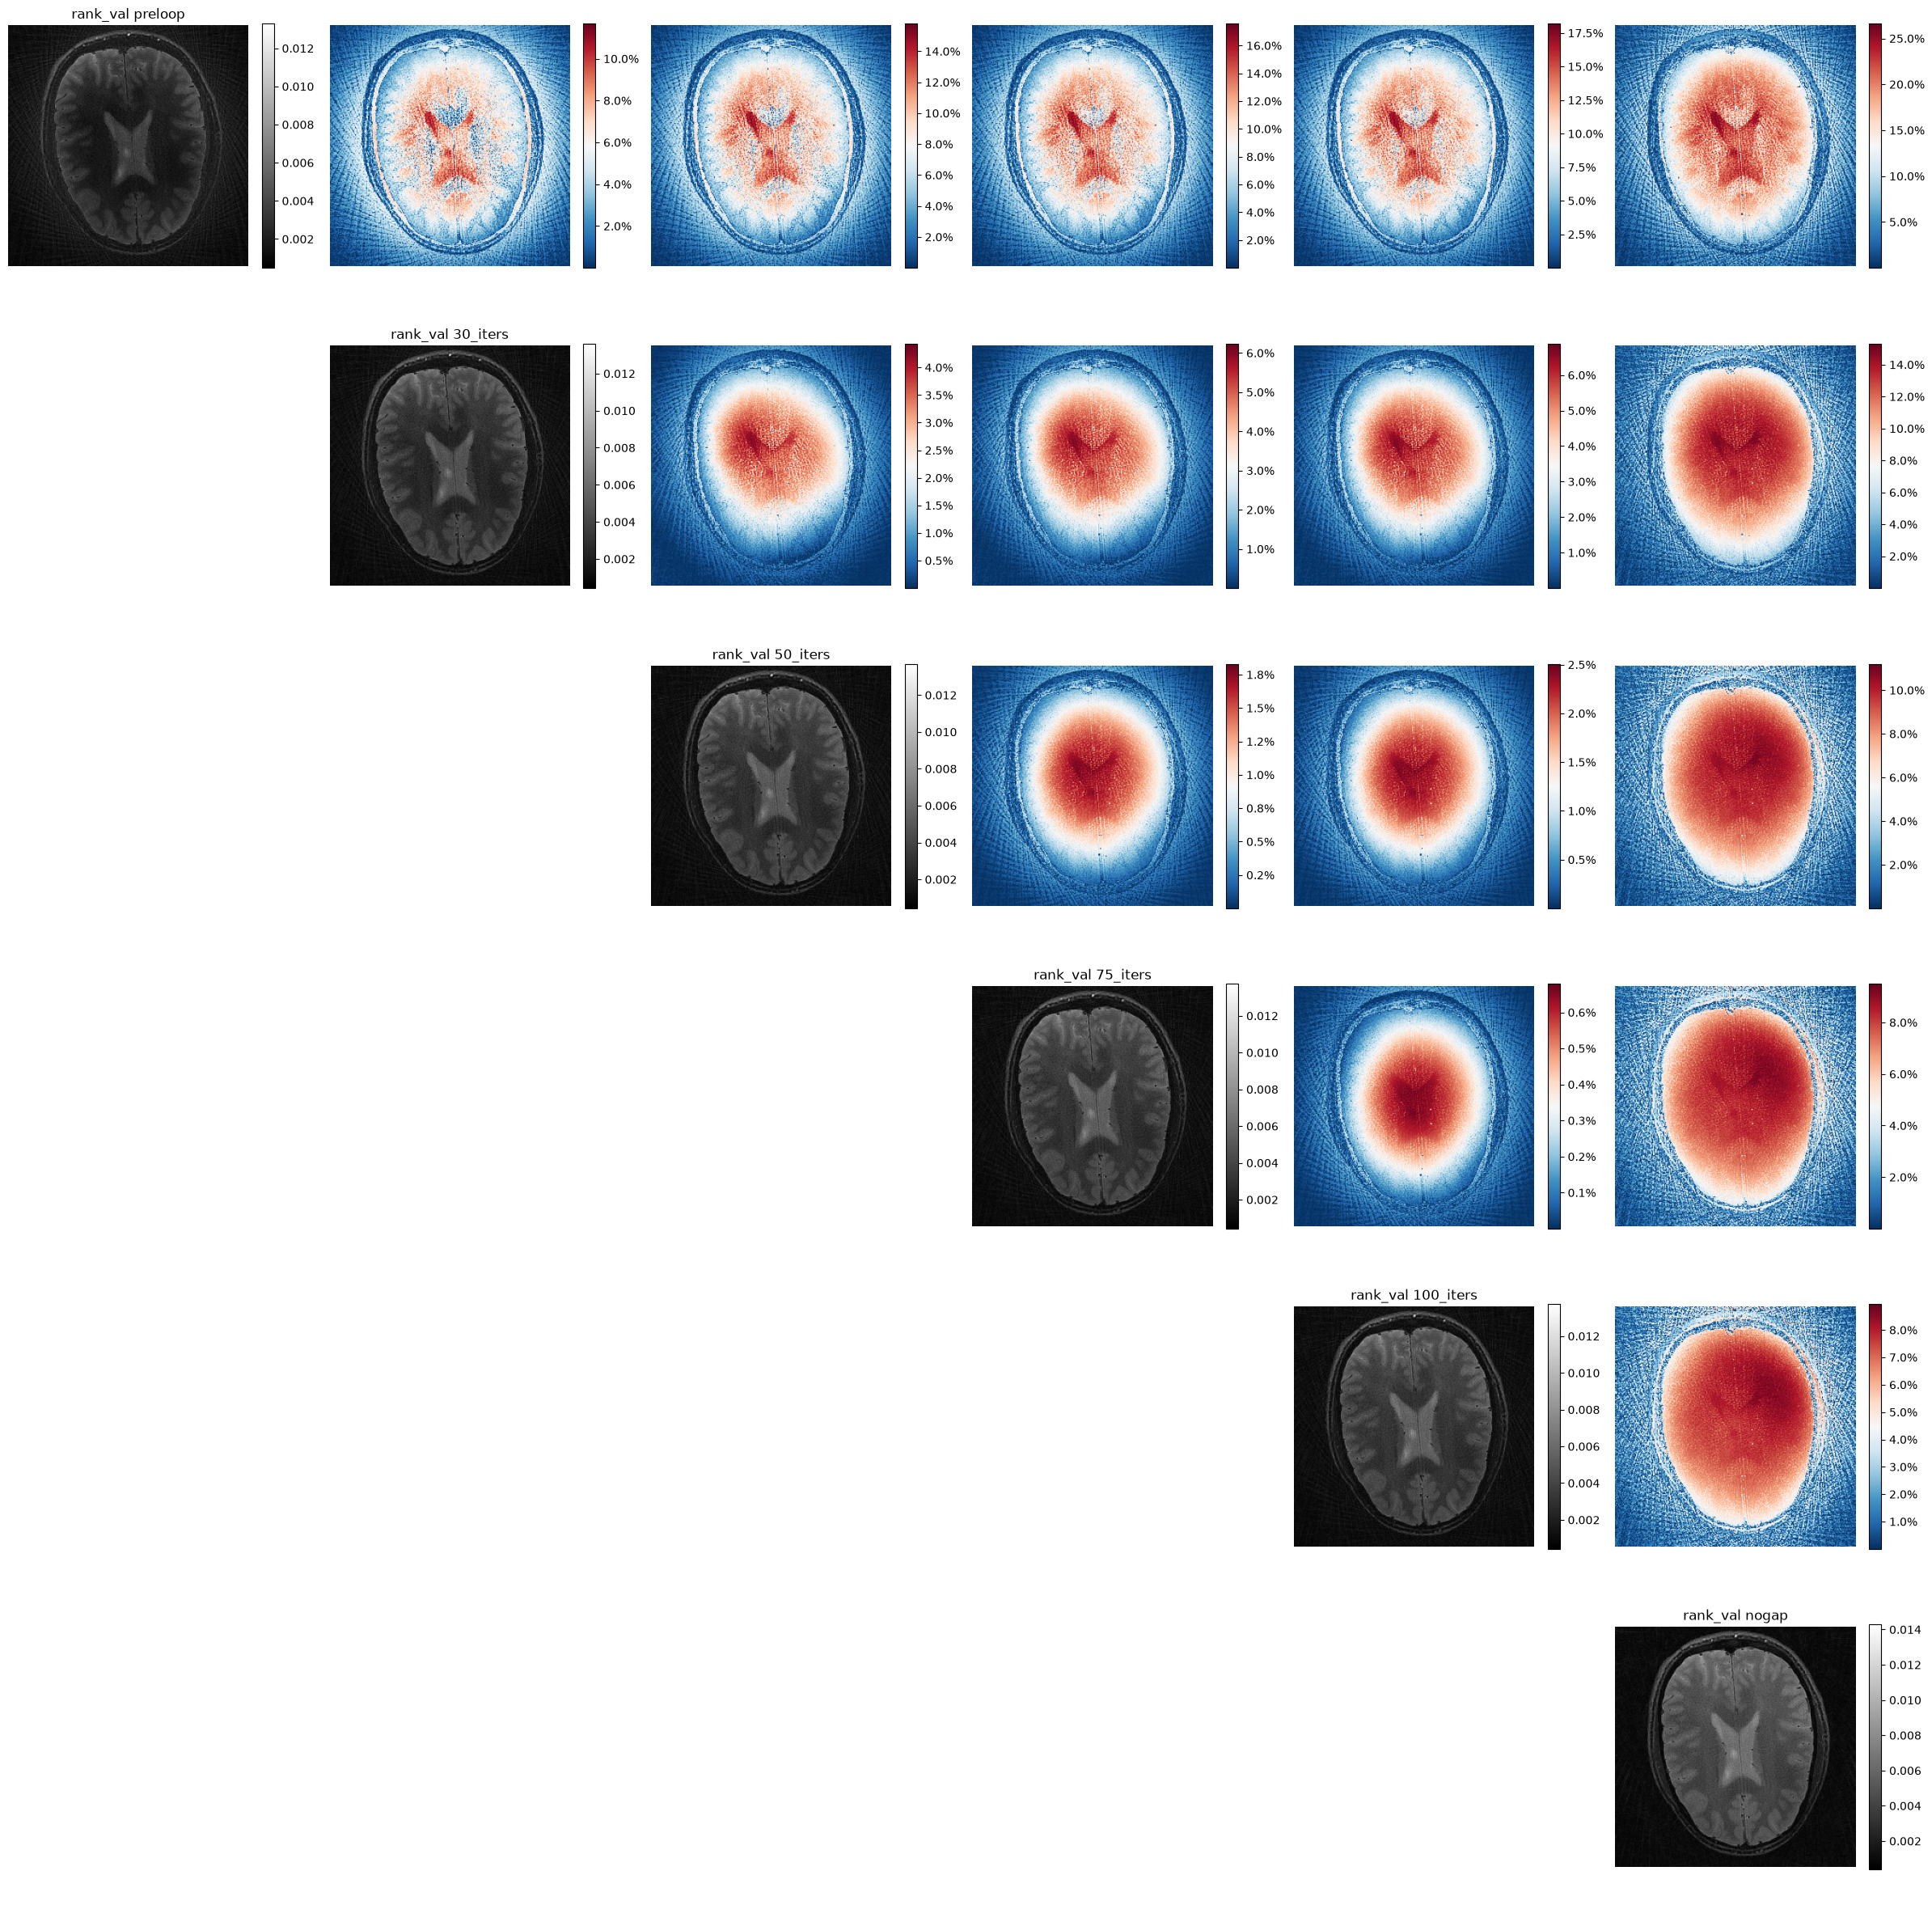

In [ ]:
iter_count = {'30_iters': 30, '50_iters': 50, '75_iters': 75, '100_iters': 100}
window_size = 5
stride_len = 1
num_iters = 50
thresh=0.2
cartesian_input = inner_region.copy()

results = {}
results['preloop'] = {'im': preloop} 
for name, iters in iter_count.items():
    im, cart, delta = LORAKS_loop(iters, window_size, thresh, cartesian_input, maskb, stride_len, 256, 256)
    results[name] = {'im': im}

results['nogap'] = {'im': img_nogap}

imsvd = {f'itercount {r}': results[r]['im'] for r in results}
asm.diff_matrix(imsvd)

### IterCount ALS

In [50]:
iter_count = {'50_iters': 50, '75_iters': 75, '100_iters': 100}
win = 10
stride_len = 1
num_iters = 50
thresh=0.2
cartesian_input = inner_region.copy()

results = {}
results['preloop'] = {'im': preloop} 
for name, iters in iter_count.items():
    im_als, cart, delta = LORAKS_imputeals(n_iters = iters,window_size=win, cartesian_inputkspace = cartesian_input, dtg_mask = maskb, rank=10,lamda=5*10**-5, stride=1, im_dim=256)
    (iters, window_size, thresh, cartesian_input, maskb, stride_len, 256, 256)
    results[name] = {'im': im_als}

results['nogap'] = {'im': img_nogap}

imsals = {f'rank_val {r}': results[r]['im'] for r in results}
asm.diff_matrix(imsals)

KeyboardInterrupt: 